In [12]:
# ============================================================
# 🚚 SUPPLY CHAIN DELAY PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix




In [13]:
np.random.seed(42)
n = 100

data = {
    'distance_km': np.random.randint(5, 200, n),
    'traffic_level': np.random.randint(1, 4, n),
    'weather_condition': np.random.randint(1, 4, n),
    'vehicle_capacity': np.random.randint(50, 100, n),
    'delivery_priority': np.random.randint(1, 4, n),
    'driver_experience': np.random.randint(1, 10, n),
    'fuel_status': np.random.randint(10, 100, n),
    'road_type': np.random.randint(1, 3, n),
    'time_of_day': np.random.randint(1, 4, n)
}

df = pd.DataFrame(data)

In [14]:
df['delay'] = (
    ((df['distance_km'] > 120) & (df['traffic_level'] == 3)) |
    (df['weather_condition'] == 3) |
    (df['vehicle_capacity'] > 90) |
    (df['driver_experience'] < 3) |
    (df['fuel_status'] < 30)
).astype(int)

print("📊 Dataset Preview:")
print(df.head())

print("\nTotal Records:", len(df))

📊 Dataset Preview:
   distance_km  traffic_level  weather_condition  vehicle_capacity  \
0          107              1                  2                67   
1          184              1                  3                95   
2           97              3                  3                67   
3           19              1                  2                51   
4          111              1                  1                84   

   delivery_priority  driver_experience  fuel_status  road_type  time_of_day  \
0                  2                  5           16          1            2   
1                  3                  7           55          1            1   
2                  1                  6           22          2            2   
3                  1                  5           49          1            2   
4                  1                  4           51          2            3   

   delay  
0      1  
1      1  
2      1  
3      0  
4      0  

Total Record

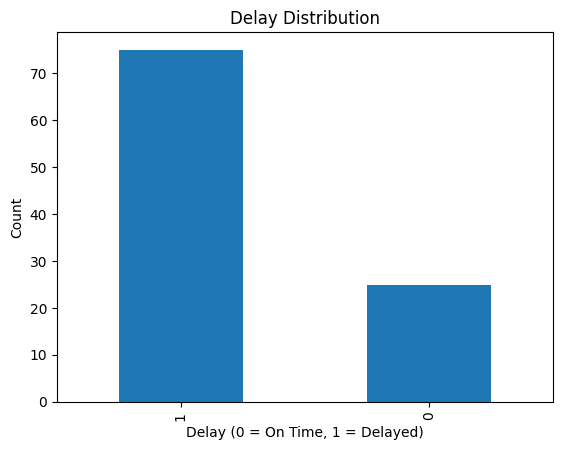

In [15]:
plt.figure()
df['delay'].value_counts().plot(kind='bar')
plt.title("Delay Distribution")
plt.xlabel("Delay (0 = On Time, 1 = Delayed)")
plt.ylabel("Count")
plt.show()

In [16]:
X = df.drop('delay', axis=1)
y = df['delay']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(max_iter=200)
}

print("\n🤖 Model Performance:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-" * 40)


🤖 Model Performance:

Decision Tree
Accuracy: 0.9
Confusion Matrix:
 [[ 5  1]
 [ 1 13]]
----------------------------------------
Random Forest
Accuracy: 0.9
Confusion Matrix:
 [[ 4  2]
 [ 0 14]]
----------------------------------------
Logistic Regression
Accuracy: 0.7
Confusion Matrix:
 [[ 4  2]
 [ 4 10]]
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X, y)


RandomForestClassifier()

In [20]:
RandomForestClassifier()

RandomForestClassifier()

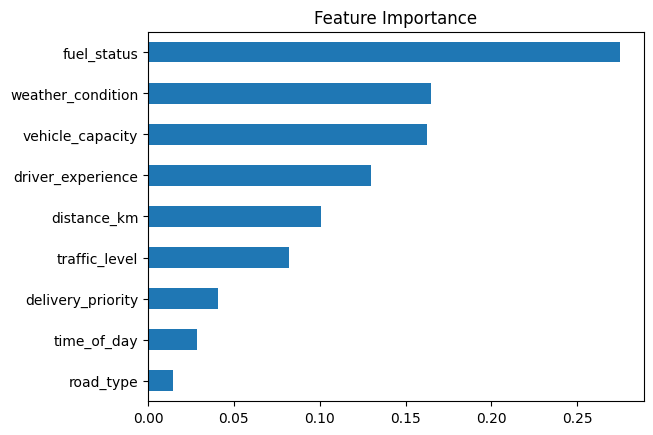

In [21]:
importance = model.feature_importances_
features = X.columns

plt.figure()
pd.Series(importance, index=features).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()



In [26]:
# ============================================================
# Step 11: Test New Delivery Scenario (No Input)
# ============================================================

print("\n🔮 Test Scenario")

# distance, traffic, weather, capacity, priority, experience, fuel, road, time
sample_data = [[120, 3, 2, 85, 2, 5, 70, 1, 2]]
sample = pd.DataFrame(sample_data, columns=X.columns)

prediction = model.predict(sample)

print("\n📢 Prediction Result:")

if prediction[0] == 1:
    print("🚨 Delivery Delay Expected")
else:
    print("✅ Delivery On Time")


🔮 Test Scenario

📢 Prediction Result:
🚨 Delivery Delay Expected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [27]:
# Save files
df.to_csv("supply_chain_data.csv", index=False)

df.to_excel("supply_chain_data.xlsx", index=False)

print("📁 Files saved successfully!")

📁 Files saved successfully!


In [28]:
from google.colab import files

files.download("supply_chain_data.csv")
files.download("supply_chain_data.xlsx")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>